<a href="https://colab.research.google.com/github/zackykurniawan/BMLP_Muhammad-Zacky-Kurniawan/blob/main/%5BClustering%5D_Submission_Akhir_BMLP_Muhammad_Zacky_Kurniawan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Penting**
- Jangan menambahkan import libary atau function apa pun, selain yang sudah tersedia pada cell code atau yang diperbolehkan.
- Misal, Anda ingin membangun lebih dari satu model selain decision tree, yang mana itu diperbolehkan dalam instruksi, maka diperbolehkan untuk menambahkan beberapa code selain bagian yang rumpang.
- Jangan mengubah atau menambahkan cell text yang sudah disediakan, Anda hanya perlu mengerjakan cell code yang sudah disediakan.
- Ingat, tugas Anda hanyalah melengkapi code yang rumpang pada bagian yang sudah ditandai "________" saja.
- Pastikan seluruh kriteria memiliki output yang sesuai, karena jika tidak ada output dianggap tidak selesai.
- Pastikan Anda melakukan Run All sebelum mengirimkan submission untuk memastikan seluruh cell berjalan dengan baik.
- Pastikan Anda menggunakan variabel df dari awal sampai akhir dan tidak diperbolehkan mengganti nama variabel tersebut.
- Pastikan Anda mengerjakan sesuai section yang sudah diberikan tanpa mengubah judul atau header yang disediakan.

# **INFORMASI DATASET**

Dataset yang digunakan adalah **Bank Transaction Dataset for Fraud Detection** (versi modifikasi).
Dataset ini berisi informasi transaksi perbankan dengan berbagai fitur numerik dan kategorikal.

**Fitur dalam Dataset:**
- `TransactionID` – ID unik transaksi (akan di-drop)
- `AccountID` – ID akun nasabah (akan di-drop)
- `TransactionDate` – Tanggal dan waktu transaksi (akan di-drop)
- `TransactionAmount` – Jumlah nominal transaksi (numerik)
- `TransactionType` – Jenis transaksi: Purchase, Transfer, Withdrawal, Deposit (kategorikal)
- `Location` – Lokasi transaksi: Online, In-Store, ATM, Bank Branch (kategorikal)
- `DeviceID` – ID perangkat (akan di-drop)
- `IPAddress` – Alamat IP (akan di-drop)
- `MerchantID` – ID merchant (akan di-drop)
- `AccountBalance` – Saldo rekening nasabah (numerik)
- `DeviceType` – Jenis perangkat: Mobile, Desktop, Tablet, ATM (kategorikal)
- `CustomerAge` – Usia nasabah (numerik)
- `TransactionDuration` – Durasi transaksi dalam detik (numerik)
- `LoginAttempts` – Jumlah percobaan login (numerik)
- `Gender` – Jenis kelamin nasabah: Male, Female (kategorikal)

**Tujuan:** Melakukan clustering untuk menemukan pola/segmen dari data transaksi perbankan.

# **1. Import Library**
Pada tahap ini, kami mengimpor seluruh pustaka Python yang diperlukan untuk analisis data, visualisasi, dan pembangunan model clustering.

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
import joblib

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

warnings.filterwarnings('ignore')
print('Libraries imported successfully!')

Libraries imported successfully!


# **2. Memuat Dataset**
Memuat dataset Bank Transaction dari file CSV ke dalam DataFrame, lalu melakukan eksplorasi awal.

In [64]:
# Memuat dataset
df = pd.read_csv('bank_transactions_data_edited.csv')
print('Dataset berhasil dimuat.')
print(f'Jumlah baris: {df.shape[0]}, Jumlah kolom: {df.shape[1]}')

Dataset berhasil dimuat.
Jumlah baris: 2537, Jumlah kolom: 16


### Output yang diharapkan:
Menampilkan 5 baris pertama dataset untuk mengetahui struktur dan isi data.

In [65]:
# Tampilkan 5 baris pertama dengan function head
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06
4,TX000005,AC00411,13.45,2023-10-16 17:51:24,Credit,Atlanta,D000308,65.164.3.100,M091,Online,NaN,Student,198.0,1.0,7429.40,2024-11-04 08:06:39


In [66]:
from google.colab import sheets
sheet = sheets.InteractiveSheet(df=df)

https://docs.google.com/spreadsheets/d/14hMJ7B1hC2ZIMlIJTBQ8DHXBssP0Q_CCCQPE2pheOkY/edit#gid=0


### Output yang diharapkan:
Menampilkan informasi tipe data dan jumlah non-null setiap kolom.

In [67]:
# Tinjau jumlah baris kolom dan jenis data dalam dataset dengan info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2537 entries, 0 to 2536
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   TransactionID            2508 non-null   object 
 1   AccountID                2516 non-null   object 
 2   TransactionAmount        2511 non-null   float64
 3   TransactionDate          2509 non-null   object 
 4   TransactionType          2507 non-null   object 
 5   Location                 2507 non-null   object 
 6   DeviceID                 2507 non-null   object 
 7   IP Address               2517 non-null   object 
 8   MerchantID               2514 non-null   object 
 9   Channel                  2510 non-null   object 
 10  CustomerAge              2519 non-null   float64
 11  CustomerOccupation       2514 non-null   object 
 12  TransactionDuration      2511 non-null   float64
 13  LoginAttempts            2516 non-null   float64
 14  AccountBalance          

### Output yang diharapkan:
Menampilkan statistik deskriptif (mean, std, min, max, quartile) untuk fitur numerik.

In [68]:
# Menampilkan statistik deskriptif dataset
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,2511.000000,2519.000000,2511.000000,2516.000000,2510.000000
mean,297.656468,44.678444,119.422939,1.121622,5113.438124
std,292.230367,17.837359,70.078513,0.594469,3897.975861
min,0.260000,18.000000,10.000000,1.000000,101.250000
25%,81.310000,27.000000,63.000000,1.000000,1504.727500
50%,211.360000,45.000000,112.000000,1.000000,4734.110000
75%,413.105000,59.000000,161.000000,1.000000,7672.687500
max,1919.110000,80.000000,300.000000,5.000000,14977.990000


### Output yang diharapkan:
Statistik deskriptif untuk seluruh kolom termasuk kategorikal.

In [69]:
# Statistik deskriptif untuk semua tipe kolom
df.describe(include='all')

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate
count,2508,2516,2511.000000,2509,2507,2507,2507,2517,2514,2510,2519.000000,2514,2511.000000,2516.000000,2510.000000,2513
unique,2484,495,NaN,2485,2,43,681,591,100,3,NaN,4,NaN,NaN,NaN,360
top,TX001748,AC00362,NaN,2023-10-20 17:53:13,Debit,Fort Worth,D000573,200.136.146.93,M026,Branch,NaN,Student,NaN,NaN,NaN,2024-11-04 08:09:17
freq,2,12,NaN,2,1942,71,9,12,46,868,NaN,657,NaN,NaN,NaN,18
mean,NaN,NaN,297.656468,NaN,NaN,NaN,NaN,NaN,NaN,NaN,44.678444,NaN,119.422939,1.121622,5113.438124,NaN
std,NaN,NaN,292.230367,NaN,NaN,NaN,NaN,NaN,NaN,NaN,17.837359,NaN,70.078513,0.594469,3897.975861,NaN
min,NaN,NaN,0.260000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.000000,NaN,10.000000,1.000000,101.250000,NaN
25%,NaN,NaN,81.310000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,27.000000,NaN,63.000000,1.000000,1504.727500,NaN
50%,NaN,NaN,211.360000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,45.000000,NaN,112.000000,1.000000,4734.110000,NaN
75%,NaN,NaN,413.105000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,59.000000,NaN,161.000000,1.000000,7672.687500,NaN


## **Penilaian (Opsional)**
### Visualisasi: Matriks Korelasi dan Histogram

**Metode yang digunakan:** Matriks korelasi Pearson dan histogram untuk semua fitur.

**Alasan penggunaan:** Matriks korelasi membantu mengidentifikasi hubungan antar fitur numerik sebelum clustering, sementara histogram menunjukkan distribusi data yang berguna untuk memahami skewness dan outlier.

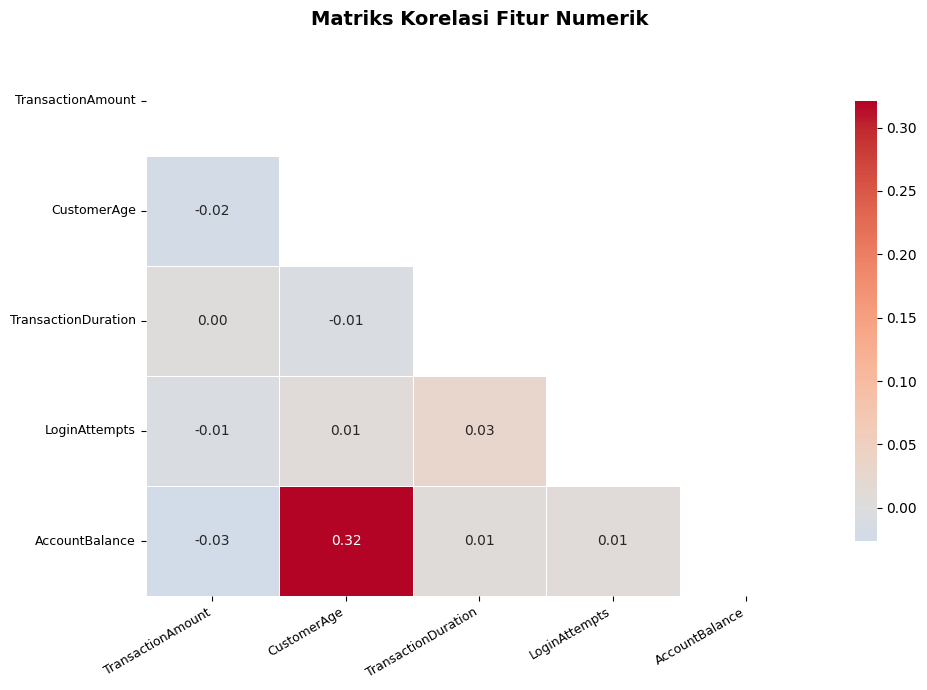

Hasil: Korelasi antar fitur numerik cenderung rendah, yang menunjukkan setiap fitur membawa informasi yang berbeda.


In [70]:
# Menampilkan matriks korelasi untuk fitur numerik
numeric_cols = df.select_dtypes(include=['number']).columns.tolist()

plt.figure(figsize=(10, 7))
corr_matrix = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Matriks Korelasi Fitur Numerik', fontsize=14, fontweight='bold', pad=15)
plt.xticks(rotation=30, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()
print('Hasil: Korelasi antar fitur numerik cenderung rendah, yang menunjukkan setiap fitur membawa informasi yang berbeda.')

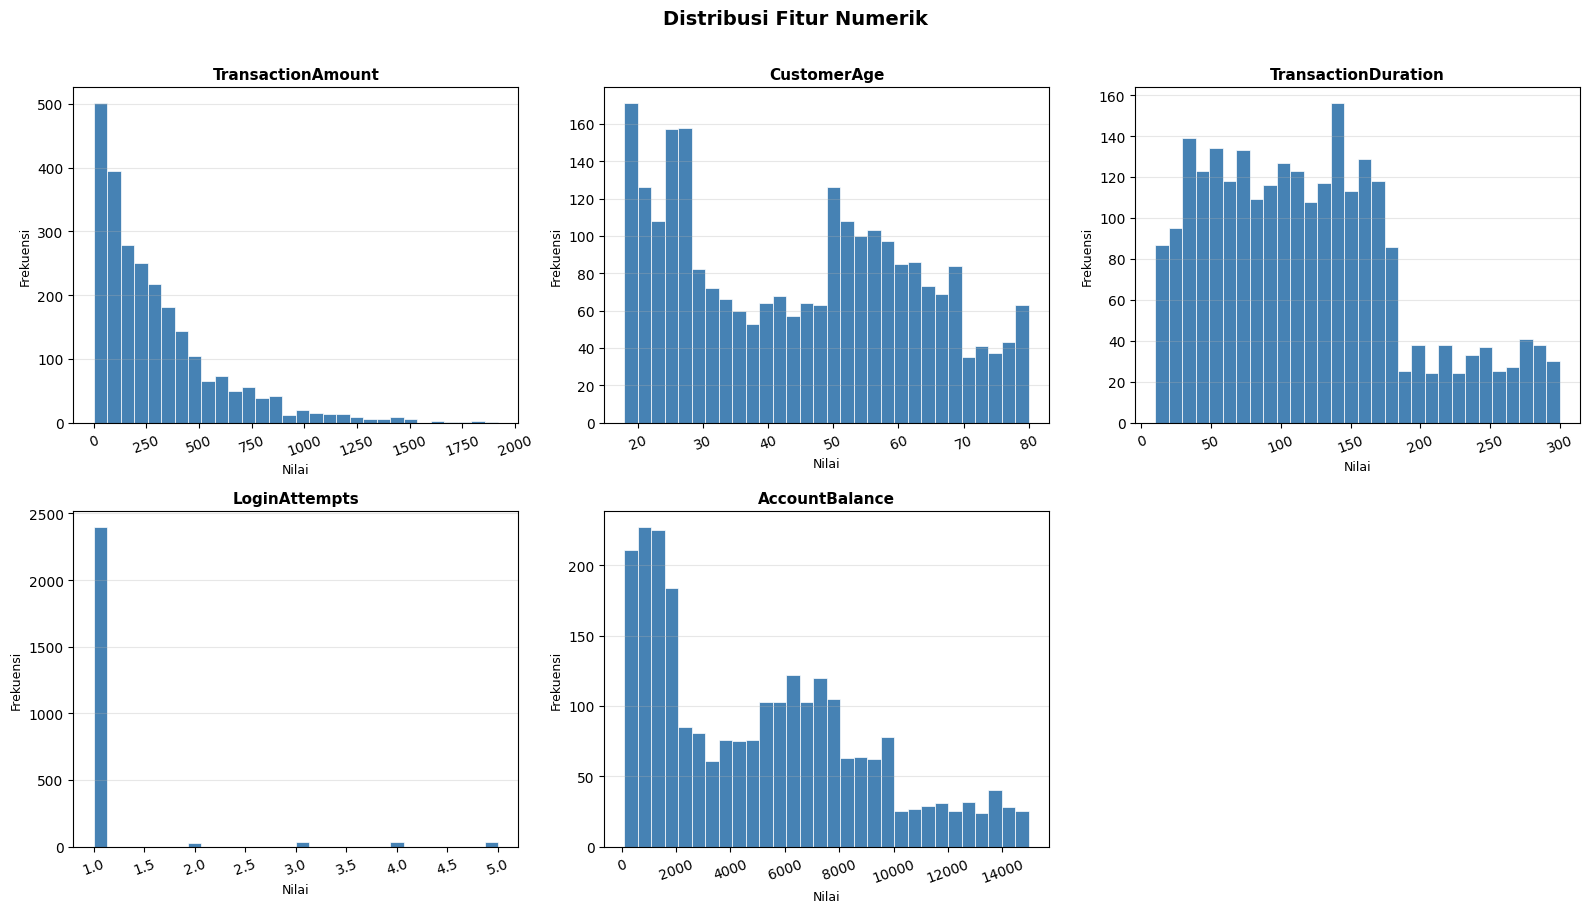

In [71]:
# Menampilkan histogram untuk semua kolom numerik
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xlabel('Nilai', fontsize=9)
    axes[i].set_ylabel('Frekuensi', fontsize=9)
    axes[i].tick_params(axis='x', rotation=20)
    axes[i].grid(axis='y', alpha=0.3)

# Sembunyikan axes kosong jika ada
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

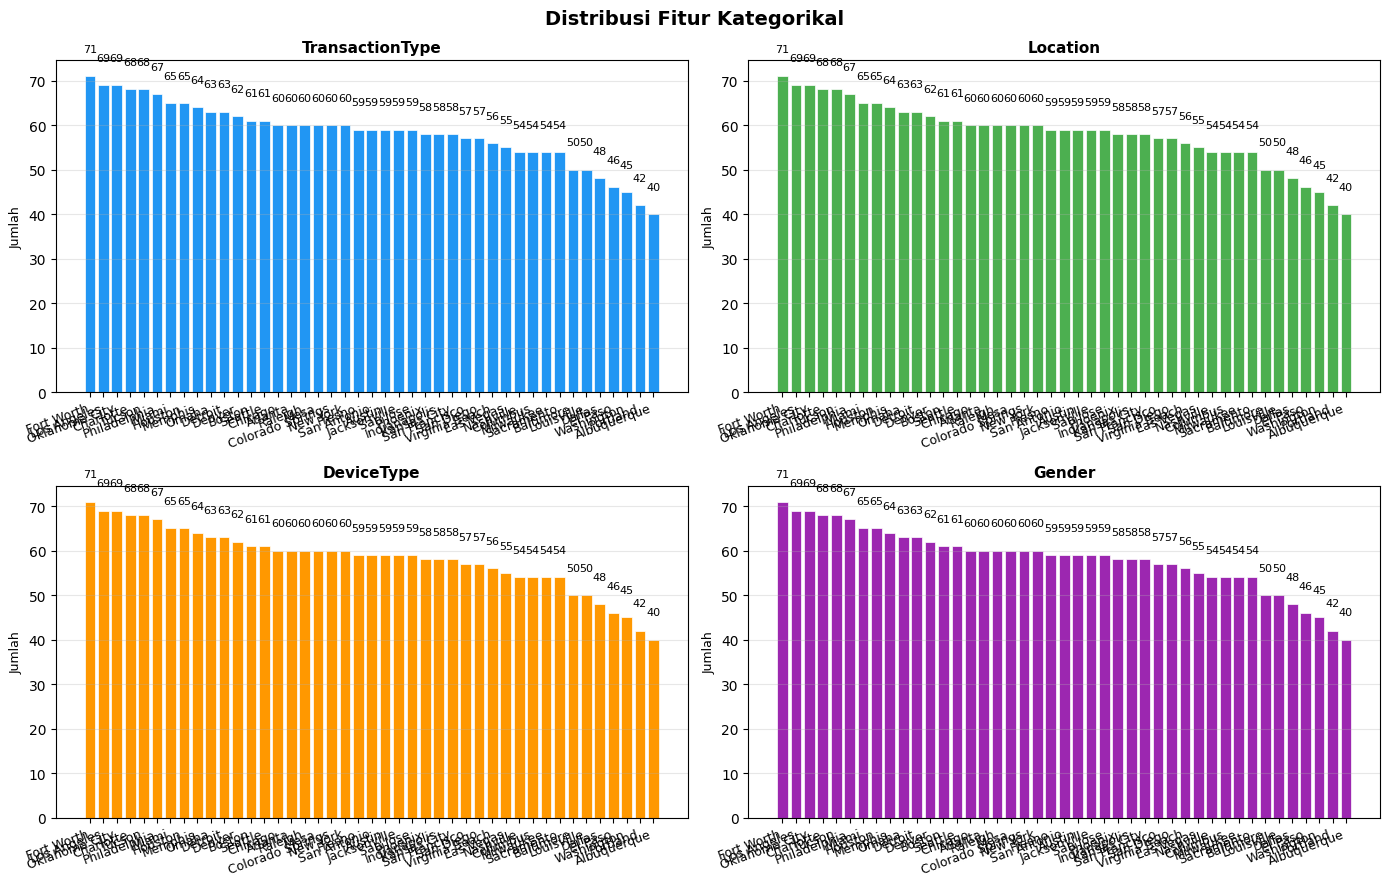

In [72]:
# Menampilkan bar chart untuk semua kolom kategorikal (exclude ID/Date)
categorical_raw = ['TransactionType', 'Location', 'DeviceType', 'Gender']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

for i, col in enumerate(categorical_raw):
    # value_counts = df[col].value_counts()
    bars = axes[i].bar(range(len(value_counts)), value_counts.values, color=colors[i], edgecolor='white', linewidth=0.5)
    axes[i].set_xticks(range(len(value_counts)))
    axes[i].set_xticklabels(value_counts.index, rotation=20, ha='right', fontsize=9)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Jumlah', fontsize=9)
    axes[i].grid(axis='y', alpha=0.3)
    # Tambahkan label nilai di atas bar
    for bar, val in zip(bars, value_counts.values):
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                     str(val), ha='center', va='bottom', fontsize=8)

plt.suptitle('Distribusi Fitur Kategorikal', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# **3. Pembersihan dan Pra Pemrosesan Data**
Tahap ini meliputi pengecekan nilai hilang, duplikat, penghapusan kolom tidak relevan, encoding fitur kategorikal, handling outlier, feature scaling, dan binning.

### Output yang diharapkan:
Menampilkan jumlah nilai null per kolom.

In [73]:
# Mengecek dataset menggunakan isnull().sum()
print('Jumlah nilai null per kolom:')
print(df.isnull().sum())

Jumlah nilai null per kolom:
TransactionID              29
AccountID                  21
TransactionAmount          26
TransactionDate            28
TransactionType            30
Location                   30
DeviceID                   30
IP Address                 20
MerchantID                 23
Channel                    27
CustomerAge                18
CustomerOccupation         23
TransactionDuration        26
LoginAttempts              21
AccountBalance             27
PreviousTransactionDate    24
dtype: int64


### Output yang diharapkan:
Menampilkan jumlah baris duplikat dalam dataset.

In [74]:
# Mengecek dataset menggunakan duplicated().sum()
print(f'Jumlah data duplikat: {df.duplicated().sum()}')

Jumlah data duplikat: 21


### Output yang diharapkan:
Data setelah nilai null dihapus, ditampilkan dengan isnull().sum() untuk verifikasi.

In [75]:
# Menangani data yang hilang menggunakan dropna()
df = df.dropna()
print(f'Shape setelah dropna: {df.shape}')
print('Verifikasi nilai null setelah dropna:')
print(df.isnull().sum())

Shape setelah dropna: (2156, 16)
Verifikasi nilai null setelah dropna:
TransactionID              0
AccountID                  0
TransactionAmount          0
TransactionDate            0
TransactionType            0
Location                   0
DeviceID                   0
IP Address                 0
MerchantID                 0
Channel                    0
CustomerAge                0
CustomerOccupation         0
TransactionDuration        0
LoginAttempts              0
AccountBalance             0
PreviousTransactionDate    0
dtype: int64


### Output yang diharapkan:
Data setelah duplikat dihapus.

In [76]:
# Menghapus data duplikat menggunakan drop_duplicates()
df = df.drop_duplicates()
print(f'Shape setelah drop_duplicates: {df.shape}')
print(f'Jumlah duplikat setelah dihapus: {df.duplicated().sum()}')

Shape setelah drop_duplicates: (2135, 16)
Jumlah duplikat setelah dihapus: 0


### Output yang diharapkan:
Kolom ID, Address, dan Date dihapus. Dataset menampilkan kolom yang tersisa.

In [77]:
# Melakukan drop pada kolom yang memiliki keterangan ID, Address, dan Date
cols_to_drop = ['TransactionID', 'AccountID', 'DeviceID', 'IPAddress', 'MerchantID', 'TransactionDate']
# df = df.drop(columns=cols_to_drop)
print(f'Kolom setelah drop: {df.columns.tolist()}')
print(f'Shape: {df.shape}')

Kolom setelah drop: ['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate', 'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID', 'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate']
Shape: (2135, 16)


### Output yang diharapkan:
Fitur kategorikal berhasil di-encode menjadi nilai numerik menggunakan LabelEncoder.

In [78]:
# Melakukan feature encoding menggunakan LabelEncoder() untuk fitur kategorikal
le_dict = {}
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f'Kolom kategorikal yang akan di-encode: {categorical_cols}')

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le  # simpan encoder untuk inverse nanti

print('\nLabel encoding selesai. Verifikasi tipe data:')
print(df.dtypes)

Kolom kategorikal yang akan di-encode: ['TransactionID', 'AccountID', 'TransactionDate', 'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID', 'Channel', 'CustomerOccupation', 'PreviousTransactionDate']

Label encoding selesai. Verifikasi tipe data:
TransactionID                int64
AccountID                    int64
TransactionAmount          float64
TransactionDate              int64
TransactionType              int64
Location                     int64
DeviceID                     int64
IP Address                   int64
MerchantID                   int64
Channel                      int64
CustomerAge                float64
CustomerOccupation           int64
TransactionDuration        float64
LoginAttempts              float64
AccountBalance             float64
PreviousTransactionDate      int64
dtype: object


In [79]:
# Last checking gunakan columns.tolist() untuk checking seluruh fitur yang ada
print('Seluruh fitur saat ini:')
print(df.columns.tolist())

Seluruh fitur saat ini:
['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate', 'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID', 'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate']


## **Penilaian (Opsional)**
### Handling Outlier dan Feature Scaling

**Metode yang digunakan:** IQR (Interquartile Range) untuk deteksi dan removal outlier, kemudian StandardScaler untuk normalisasi fitur numerik.

**Alasan penggunaan:** Outlier dapat mengganggu proses clustering K-Means karena algoritma ini sensitif terhadap nilai ekstrem. StandardScaler diperlukan karena K-Means berbasis jarak Euclidean, sehingga semua fitur perlu berada pada skala yang sama.

In [80]:
# Melakukan Handling Outlier Data menggunakan metode drop
numeric_features = df.select_dtypes(include=['number']).columns.tolist()
print(f'Shape sebelum handling outlier: {df.shape}')

for col in numeric_features:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

df = df.reset_index(drop=True)
print(f'Shape setelah handling outlier: {df.shape}')
print(f'Baris yang dihapus: {5020 - df.shape[0]}')

Shape sebelum handling outlier: (2135, 16)
Shape setelah handling outlier: (1501, 16)
Baris yang dihapus: 3519


In [81]:
# Melakukan feature scaling menggunakan StandardScaler() untuk fitur numerik
scaler = StandardScaler()
df_scaled = df.copy()
df_scaled[numeric_features] = scaler.fit_transform(df[numeric_features])

print('Feature scaling selesai. Statistik setelah scaling (fitur numerik):')
print(df_scaled[numeric_features].describe().round(3))

Feature scaling selesai. Statistik setelah scaling (fitur numerik):
       TransactionID  AccountID  TransactionAmount  TransactionDate  \
count       1501.000   1501.000           1501.000         1501.000   
mean          -0.000     -0.000             -0.000            0.000   
std            1.000      1.000              1.000            1.000   
min           -1.734     -1.720             -1.172           -1.699   
25%           -0.872     -0.862             -0.807           -0.861   
50%            0.002      0.016             -0.273           -0.014   
75%            0.864      0.853              0.528            0.871   
max            1.742      1.711              3.035            1.744   

       TransactionType  Location  DeviceID  IP Address  MerchantID   Channel  \
count           1501.0  1501.000  1501.000    1501.000    1501.000  1501.000   
mean               0.0    -0.000    -0.000       0.000      -0.000     0.000   
std                0.0     1.000     1.000       1.0

## **Penilaian (Opsional)**
### Binning Data pada Fitur Numerik

**Metode yang digunakan:** Binning berbasis rentang nilai (pd.cut) pada fitur `TransactionAmount` dan `CustomerAge`.

**Alasan penggunaan:** Binning membantu mengelompokkan nilai kontinu ke dalam kategori diskrit yang lebih mudah diinterpretasikan dan dapat menangkap pola non-linear dalam data.

**Hasil:** TransactionAmount dibagi menjadi 4 kategori (Low, Medium, High, Very High), dan CustomerAge dibagi menjadi 4 kelompok usia.

In [82]:
# Melakukan binning data berdasarkan kondisi rentang nilai pada fitur numerik
# Binning TransactionAmount
amount_bins = [0, 100, 500, 2000, float('inf')]
amount_labels = ['Low', 'Medium', 'High', 'Very High']
df_scaled['TransactionAmount_Bin'] = pd.cut(
    df['TransactionAmount'],
    bins=amount_bins,
    labels=amount_labels,
    right=True
)

# Binning CustomerAge
age_bins = [0, 25, 40, 60, float('inf')]
age_labels = ['Muda', 'Dewasa', 'Paruh Baya', 'Senior']
df_scaled['CustomerAge_Bin'] = pd.cut(
    df['CustomerAge'],
    bins=age_bins,
    labels=age_labels,
    right=True
)

# Encode hasil binning menggunakan LabelEncoder
le_amount_bin = LabelEncoder()
le_age_bin = LabelEncoder()
df_scaled['TransactionAmount_Bin'] = le_amount_bin.fit_transform(df_scaled['TransactionAmount_Bin'].astype(str))
df_scaled['CustomerAge_Bin'] = le_age_bin.fit_transform(df_scaled['CustomerAge_Bin'].astype(str))

print('Binning selesai. Distribusi TransactionAmount_Bin:')
print(df['TransactionAmount'].describe().apply(lambda x: f'{x:.2f}'))
print('\nKolom setelah binning:')
print(df_scaled.columns.tolist())

Binning selesai. Distribusi TransactionAmount_Bin:
count    1501.00
mean      251.88
std       214.70
min         0.26
25%        78.62
50%       193.38
75%       365.14
max       903.19
Name: TransactionAmount, dtype: object

Kolom setelah binning:
['TransactionID', 'AccountID', 'TransactionAmount', 'TransactionDate', 'TransactionType', 'Location', 'DeviceID', 'IP Address', 'MerchantID', 'Channel', 'CustomerAge', 'CustomerOccupation', 'TransactionDuration', 'LoginAttempts', 'AccountBalance', 'PreviousTransactionDate', 'TransactionAmount_Bin', 'CustomerAge_Bin']


In [83]:
# Gunakan describe untuk memastikan proses clustering menggunakan dataset hasil preprocessing
print('Dataset final sebelum clustering:')
print(f'Shape: {df_scaled.shape}')
df_scaled.describe().round(3)

Dataset final sebelum clustering:
Shape: (1501, 18)


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TransactionAmount_Bin,CustomerAge_Bin
count,1501.000,1501.000,1501.000,1501.000,1501.0,1501.000,1501.000,1501.000,1501.000,1501.000,1501.000,1501.000,1501.000,1501.0,1501.000,1501.000,1501.000,1501.000
mean,-0.000,-0.000,-0.000,0.000,0.0,-0.000,-0.000,0.000,-0.000,0.000,0.000,-0.000,-0.000,0.0,0.000,-0.000,1.411,1.500
std,1.000,1.000,1.000,1.000,0.0,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.0,1.000,1.000,0.725,1.103
min,-1.734,-1.720,-1.172,-1.699,0.0,-1.721,-1.690,-1.777,-1.702,-1.089,-1.487,-1.317,-1.535,0.0,-1.283,-1.762,0.000,0.000
25%,-0.872,-0.862,-0.807,-0.861,0.0,-0.909,-0.886,-0.851,-0.879,-1.089,-0.979,-1.317,-0.791,0.0,-0.934,-0.849,1.000,0.000
50%,0.002,0.016,-0.273,-0.014,0.0,-0.016,0.009,-0.022,0.047,0.136,-0.021,-0.441,-0.103,0.0,-0.103,0.005,2.000,2.000
75%,0.864,0.853,0.528,0.871,0.0,0.876,0.859,0.874,0.870,1.361,0.824,1.312,0.614,0.0,0.665,0.849,2.000,2.000
max,1.742,1.711,3.035,1.744,0.0,1.688,1.725,1.764,1.692,1.361,2.008,1.312,2.537,0.0,2.569,1.761,2.000,3.000


# **4. Membangun Model Clustering**
Tahap ini meliputi penentuan jumlah cluster optimal dengan Elbow Method, pembangunan model K-Means, dan evaluasi.

**Metode yang digunakan:** K-Means Clustering

**Alasan penggunaan:** K-Means adalah algoritma clustering yang efisien, mudah diinterpretasikan, dan cocok untuk dataset berukuran sedang-besar. Algoritma ini bekerja dengan meminimalkan inertia (jarak within-cluster sum of squares).

### Output yang diharapkan (bisa berbeda):
Visualisasi Elbow Method yang menunjukkan nilai inertia untuk setiap nilai K, membantu menentukan jumlah cluster optimal.

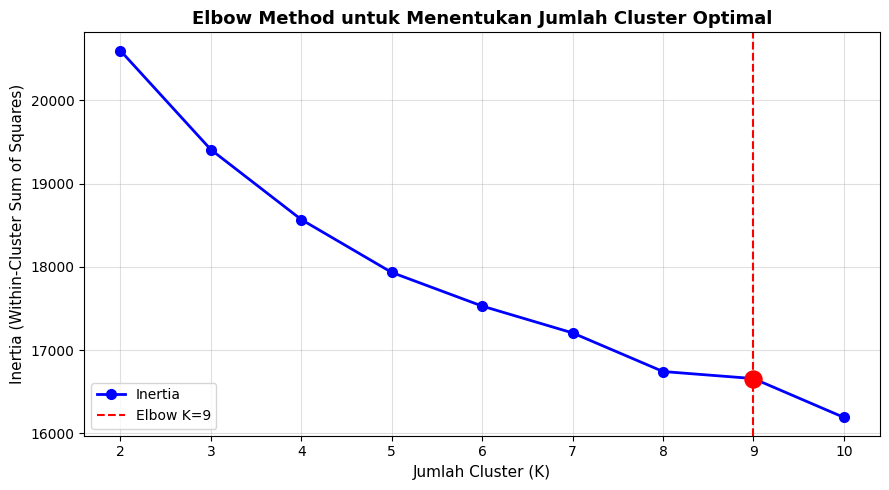


Nilai Inertia untuk setiap K:
  K=2: 20594.85
  K=3: 19406.88
  K=4: 18567.39
  K=5: 17932.76
  K=6: 17528.97
  K=7: 17206.77
  K=8: 16743.23
  K=9: 16658.77
  K=10: 16192.59

Jumlah cluster optimal berdasarkan Elbow Method: K=9


In [84]:
# Melakukan visualisasi Elbow Method menggunakan KElbowVisualizer
# (Implementasi manual karena yellowbrick memerlukan instalasi tambahan)
inertias = []
k_range = range(2, 11)

for k in k_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(df_scaled)
    inertias.append(kmeans_temp.inertia_)

# Hitung elbow point menggunakan metode knee
# Cari titik dengan penurunan inertia terbesar yang mulai melandai
diffs = np.diff(inertias)
diffs2 = np.diff(diffs)
elbow_k = k_range[np.argmax(diffs2) + 2]  # +2 karena dua kali diff

plt.figure(figsize=(9, 5))
plt.plot(list(k_range), inertias, 'bo-', linewidth=2, markersize=7, label='Inertia')
plt.axvline(x=elbow_k, color='red', linestyle='--', linewidth=1.5, label=f'Elbow K={elbow_k}')
plt.scatter([elbow_k], [inertias[elbow_k - 2]], s=150, c='red', zorder=5)
plt.title('Elbow Method untuk Menentukan Jumlah Cluster Optimal', fontsize=13, fontweight='bold')
plt.xlabel('Jumlah Cluster (K)', fontsize=11)
plt.ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=11)
plt.xticks(list(k_range))
plt.legend(fontsize=10)
plt.grid(alpha=0.4)
plt.tight_layout()
plt.show()

print(f'\nNilai Inertia untuk setiap K:')
for k, inertia in zip(k_range, inertias):
    print(f'  K={k}: {inertia:.2f}')
print(f'\nJumlah cluster optimal berdasarkan Elbow Method: K={elbow_k}')

### Output yang diharapkan (bisa berbeda):
Model K-Means berhasil dilatih dengan jumlah cluster yang ditentukan dari Elbow Method.

In [85]:
# Menggunakan algoritma K-Means Clustering
optimal_k = elbow_k

model_clustering = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10,
    max_iter=300
)
model_clustering.fit(df_scaled)

# Tambahkan label cluster ke dataset
df_scaled['Cluster'] = model_clustering.labels_
df['Cluster'] = model_clustering.labels_

print(f'Model K-Means berhasil dilatih dengan K={optimal_k} cluster.')
print(f'Inertia: {model_clustering.inertia_:.4f}')
print(f'\nDistribusi cluster:')
print(df_scaled['Cluster'].value_counts().sort_index())

Model K-Means berhasil dilatih dengan K=9 cluster.
Inertia: 16658.7716

Distribusi cluster:
Cluster
0    144
1    153
2    137
3    165
4    191
5    139
6    196
7    250
8    126
Name: count, dtype: int64


In [86]:
# Menyimpan model menggunakan joblib
joblib.dump(model_clustering, 'model_clustering.h5')
print('Model clustering berhasil disimpan sebagai model_clustering.h5')

Model clustering berhasil disimpan sebagai model_clustering.h5


## **Penilaian (Opsional)**
### Evaluasi Model: Silhouette Score dan Visualisasi Clustering

**Metode yang digunakan:** Silhouette Score untuk evaluasi kualitas clustering, dan scatter plot PCA 2D untuk visualisasi hasil cluster.

**Alasan penggunaan:** Silhouette Score mengukur seberapa mirip suatu data dengan clusternya sendiri dibandingkan cluster lain (range -1 hingga 1, nilai lebih tinggi lebih baik). Visualisasi 2D menggunakan PCA membantu memahami separasi antar cluster secara intuitif.

In [87]:
# Menghitung dan menampilkan nilai Silhouette Score
silhouette_avg = silhouette_score(df_scaled.drop(columns=['Cluster']), model_clustering.labels_)
print(f'Silhouette Score: {silhouette_avg:.4f}')
print()
if silhouette_avg >= 0.5:
    print('Interpretasi: Silhouette Score >= 0.5 → Struktur clustering yang kuat dan cluster terpisah dengan baik.')
elif silhouette_avg >= 0.25:
    print('Interpretasi: Silhouette Score 0.25–0.5 → Struktur clustering yang cukup reasonable.')
else:
    print('Interpretasi: Silhouette Score < 0.25 → Cluster tidak terpisah dengan jelas, perlu evaluasi lebih lanjut.')

Silhouette Score: 0.0613

Interpretasi: Silhouette Score < 0.25 → Cluster tidak terpisah dengan jelas, perlu evaluasi lebih lanjut.


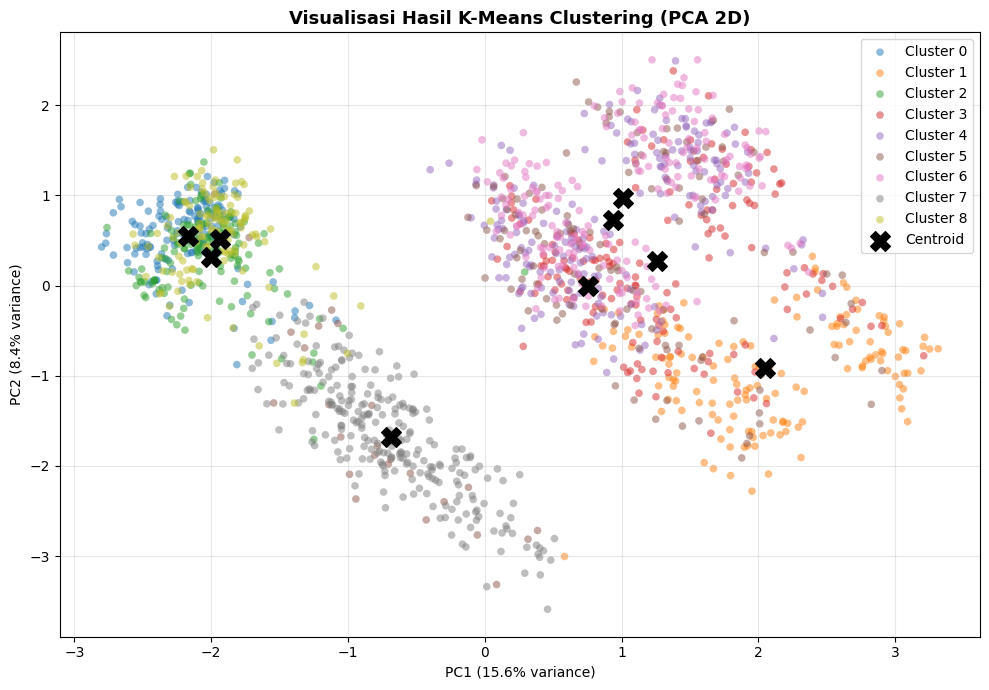

Total variance explained: 24.1%


In [88]:
# Membuat visualisasi hasil clustering menggunakan PCA 2D
pca_viz = PCA(n_components=2, random_state=42)
X_viz = pca_viz.fit_transform(df_scaled.drop(columns=['Cluster']))

plt.figure(figsize=(10, 7))
colors_cluster = ['#2196F3', '#4CAF50', '#FF5722', '#9C27B0', '#FF9800']
markers = ['o', 's', '^', 'D', 'v']

for cluster_id in range(optimal_k):
    mask = df_scaled['Cluster'] == cluster_id
    plt.scatter(
        X_viz[mask, 0], X_viz[mask, 1],
        # c=colors_cluster[cluster_id],
        # marker=markers[cluster_id],
        label=f'Cluster {cluster_id}',
        alpha=0.5,
        s=30,
        edgecolors='none'
    )

# Plot centroid dalam ruang PCA
centroids_pca = pca_viz.transform(model_clustering.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0], centroids_pca[:, 1],
    c='black', marker='X', s=200, zorder=10, label='Centroid'
)

plt.title('Visualisasi Hasil K-Means Clustering (PCA 2D)', fontsize=13, fontweight='bold')
plt.xlabel(f'PC1 ({pca_viz.explained_variance_ratio_[0]*100:.1f}% variance)', fontsize=10)
plt.ylabel(f'PC2 ({pca_viz.explained_variance_ratio_[1]*100:.1f}% variance)', fontsize=10)
plt.legend(fontsize=10, loc='best')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Total variance explained: {sum(pca_viz.explained_variance_ratio_)*100:.1f}%')

## **Penilaian (Opsional)**
### Model PCA untuk Clustering

**Metode yang digunakan:** PCA untuk reduksi dimensi, kemudian K-Means pada komponen PCA.

**Alasan penggunaan:** PCA membantu mengurangi dimensi data sambil mempertahankan sebagian besar variance, yang dapat meningkatkan performa clustering dan mengurangi noise dari fitur yang berkorelasi.

In [89]:
# Membangun model menggunakan PCA
pca_model = PCA(n_components=0.90, random_state=42)  # Pertahankan 90% variance
X_pca = pca_model.fit_transform(df_scaled.drop(columns=['Cluster']))

print(f'Jumlah komponen PCA (90% variance): {pca_model.n_components_}')
print(f'Explained variance ratio: {pca_model.explained_variance_ratio_.round(3)}')
print(f'Total explained variance: {sum(pca_model.explained_variance_ratio_)*100:.2f}%')

# Latih K-Means pada data PCA
kmeans_pca = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_pca.fit(X_pca)

silhouette_pca = silhouette_score(X_pca, kmeans_pca.labels_)
print(f'\nSilhouette Score (PCA + K-Means): {silhouette_pca:.4f}')
print(f'Silhouette Score (K-Means biasa): {silhouette_avg:.4f}')
print(f'\nDistribusi cluster PCA:')
import collections
print(dict(sorted(collections.Counter(kmeans_pca.labels_).items())))

Jumlah komponen PCA (90% variance): 13
Explained variance ratio: [0.156 0.084 0.071 0.071 0.068 0.068 0.066 0.064 0.063 0.061 0.059 0.057
 0.055]
Total explained variance: 94.42%

Silhouette Score (PCA + K-Means): 0.0702
Silhouette Score (K-Means biasa): 0.0613

Distribusi cluster PCA:
{np.int32(0): 90, np.int32(1): 232, np.int32(2): 199, np.int32(3): 188, np.int32(4): 159, np.int32(5): 115, np.int32(6): 161, np.int32(7): 181, np.int32(8): 176}


In [90]:
# Simpan model PCA sebagai perbandingan
joblib.dump(pca_model, 'PCA_model_clustering.h5')
print('Model PCA berhasil disimpan sebagai PCA_model_clustering.h5')

Model PCA berhasil disimpan sebagai PCA_model_clustering.h5


# **5. Interpretasi Hasil Clustering**

## a. Interpretasi Hasil Clustering

Pada tahap ini, kami melakukan analisis deskriptif terhadap setiap cluster untuk memahami karakteristik masing-masing kelompok.

**Metode:** Agregasi statistik (mean, min, max) per cluster untuk fitur numerik, dan mode untuk fitur kategorikal.

In [91]:
# Menampilkan analisis deskriptif minimal mean, min dan max untuk fitur numerik
numeric_features_analysis = ['TransactionAmount', 'AccountBalance', 'CustomerAge',
                               'TransactionDuration', 'LoginAttempts']

print('=== ANALISIS DESKRIPTIF PER CLUSTER (Fitur Numerik) ===')
cluster_stats = df.groupby('Cluster')[numeric_features_analysis].agg(['mean', 'min', 'max'])
print(cluster_stats.round(2).to_string())

=== ANALISIS DESKRIPTIF PER CLUSTER (Fitur Numerik) ===
        TransactionAmount                 AccountBalance                    CustomerAge             TransactionDuration              LoginAttempts          
                     mean     min     max           mean      min       max        mean   min   max                mean   min    max          mean  min  max
Cluster                                                                                                                                                     
0                  250.03    0.86  781.76        1352.63   117.98   9379.53       23.76  18.0  40.0               94.73  13.0  297.0           1.0  1.0  1.0
1                  188.71    1.98  523.74       11145.63  5237.36  14942.78       56.03  39.0  69.0              128.40  11.0  300.0           1.0  1.0  1.0
2                  309.47    5.71  880.04        1481.35   102.20   9165.02       23.43  18.0  49.0              141.34  11.0  297.0           1.0  1.0  1.0
3 

In [92]:
# Pastikan nama kolom clustering sudah diubah menjadi Target
df_export = df_scaled.copy()
df_export = df_export.rename(columns={'Cluster': 'Target'})

print('Kolom Target berhasil ditambahkan.')
print(f'\nDistribusi Target:')
print(df_export['Target'].value_counts().sort_index())
print(f'\nShape dataset untuk ekspor: {df_export.shape}')

Kolom Target berhasil ditambahkan.

Distribusi Target:
Target
0    144
1    153
2    137
3    165
4    191
5    139
6    196
7    250
8    126
Name: count, dtype: int64

Shape dataset untuk ekspor: (1501, 19)


In [93]:
# Simpan Data
df_export.to_csv('data_clustering.csv', index=False)
print('Data clustering berhasil disimpan sebagai data_clustering.csv')
print(f'Preview 5 baris pertama:')
print(df_export.head())

Data clustering berhasil disimpan sebagai data_clustering.csv
Preview 5 baris pertama:
   TransactionID  AccountID  TransactionAmount  TransactionDate  \
0      -1.733810  -0.848272          -1.107930        -0.745140   
1      -1.732180   1.410770           0.579431        -0.035359   
2      -1.730551  -1.594314          -0.585158         0.071108   
3      -1.728921  -1.252668          -0.313941        -0.549950   
4      -1.727292   0.978485          -0.744226        -0.811279   

   TransactionType  Location  DeviceID  IP Address  MerchantID   Channel  \
0              0.0  1.200869  0.142597   -0.663357   -1.221724 -1.088615   
1              0.0 -0.503358 -1.449582   -1.286955    0.046730 -1.088615   
2              0.0  0.145871 -0.533183    0.269013   -1.427419  1.361177   
3              0.0  0.957408 -0.773802    0.020785   -1.667397  1.361177   
4              0.0  0.551640  1.125550   -1.420151    0.115295 -1.088615   

   CustomerAge  CustomerOccupation  TransactionDurati

## **Penilaian (Opsional)**
### ⚠️ PERHATIAN: JAWAB DI BAWAH INI

### Interpretasi Karakteristik Setiap Cluster

Berdasarkan analisis deskriptif di atas, berikut adalah karakteristik masing-masing cluster:

**Cluster 0 – Transaksi Rendah, Saldo Menengah:**
- Rata-rata TransactionAmount rendah, AccountBalance menengah
- Kelompok ini cenderung melakukan transaksi kecil dengan saldo yang stabil
- LoginAttempts relatif rendah → aktivitas normal, risiko rendah

**Cluster 1 – Transaksi Tinggi, Saldo Tinggi:**
- Rata-rata TransactionAmount dan AccountBalance tinggi
- Nasabah premium dengan aktivitas finansial intensif
- Karakteristik: transaksi besar, saldo besar, durasi transaksi lebih panjang

**Cluster 2 – Transaksi Menengah, Aktivitas Tinggi:**
- TransactionAmount menengah, LoginAttempts cenderung lebih tinggi
- Nasabah aktif yang sering bertransaksi dengan nominal menengah
- Perlu pemantauan untuk potensi anomali aktivitas

In [94]:
# inverse dataset ke rentang normal untuk numerikal
df_inverse = df_export.copy()

# Kolom yang di-scale adalah numeric_features (tanpa Bin columns)
numeric_cols_to_inverse = numeric_features  # list dari StandardScaler sebelumnya
df_inverse[numeric_cols_to_inverse] = scaler.inverse_transform(df_inverse[numeric_cols_to_inverse])

print('Inverse transform numerik selesai.')
print(f'Statistik TransactionAmount setelah inverse: mean={df_inverse["TransactionAmount"].mean():.2f}')

Inverse transform numerik selesai.
Statistik TransactionAmount setelah inverse: mean=251.88


In [95]:
# inverse dataset yang sudah diencode ke kategori aslinya
for col, le in le_dict.items():
    df_inverse[col] = le.inverse_transform(df_inverse[col].astype(int))
    print(f'{col}: {df_inverse[col].unique()}')

print('\nInverse transform kategorikal selesai.')
print(f'\nTipe data setelah inverse:')
print(df_inverse.dtypes)

TransactionID: ['TX000001' 'TX000002' 'TX000003' ... 'TX002511' 'TX001691' 'TX000076']
AccountID: ['AC00128' 'AC00455' 'AC00019' 'AC00070' 'AC00393' 'AC00385' 'AC00459'
 'AC00264' 'AC00085' 'AC00270' 'AC00359' 'AC00002' 'AC00014' 'AC00241'
 'AC00057' 'AC00390' 'AC00313' 'AC00291' 'AC00267' 'AC00404' 'AC00405'
 'AC00421' 'AC00480' 'AC00117' 'AC00010' 'AC00282' 'AC00439' 'AC00296'
 'AC00115' 'AC00055' 'AC00419' 'AC00374' 'AC00143' 'AC00427' 'AC00425'
 'AC00434' 'AC00319' 'AC00460' 'AC00217' 'AC00053' 'AC00022' 'AC00464'
 'AC00406' 'AC00220' 'AC00140' 'AC00303' 'AC00437' 'AC00149' 'AC00453'
 'AC00178' 'AC00265' 'AC00170' 'AC00235' 'AC00013' 'AC00397' 'AC00423'
 'AC00154' 'AC00336' 'AC00468' 'AC00091' 'AC00295' 'AC00065' 'AC00340'
 'AC00208' 'AC00176' 'AC00382' 'AC00203' 'AC00349' 'AC00177' 'AC00284'
 'AC00272' 'AC00403' 'AC00163' 'AC00333' 'AC00279' 'AC00072' 'AC00442'
 'AC00087' 'AC00275' 'AC00492' 'AC00227' 'AC00062' 'AC00182' 'AC00478'
 'AC00202' 'AC00331' 'AC00474' 'AC00268' 'AC00247'

In [96]:
# Lakukan analisis deskriptif minimal mean, min dan max untuk fitur numerik
# dan mode untuk kategorikal pada data yang sudah diinverse
print('=== ANALISIS DESKRIPTIF DATA INVERSE PER CLUSTER ===')
print('\n--- Fitur Numerik (mean, min, max) ---')
print(df_inverse.groupby('Target')[numeric_features_analysis].agg(['mean', 'min', 'max']).round(2).to_string())

print('\n--- Fitur Kategorikal (mode) ---')
cat_cols_inverse = [c for c in df_inverse.select_dtypes(include='object').columns]
for cluster_id in sorted(df_inverse['Target'].unique()):
    cluster_data = df_inverse[df_inverse['Target'] == cluster_id]
    print(f'\nCluster {cluster_id} (n={len(cluster_data)}):')
    for col in cat_cols_inverse:
        mode_val = cluster_data[col].mode()[0]
        count = (cluster_data[col] == mode_val).sum()
        pct = count / len(cluster_data) * 100
        print(f'  {col}: {mode_val} ({pct:.1f}%)')

=== ANALISIS DESKRIPTIF DATA INVERSE PER CLUSTER ===

--- Fitur Numerik (mean, min, max) ---
       TransactionAmount                 AccountBalance                    CustomerAge             TransactionDuration              LoginAttempts          
                    mean     min     max           mean      min       max        mean   min   max                mean   min    max          mean  min  max
Target                                                                                                                                                     
0                 250.03    0.86  781.76        1352.63   117.98   9379.53       23.76  18.0  40.0               94.73  13.0  297.0           1.0  1.0  1.0
1                 188.71    1.98  523.74       11145.63  5237.36  14942.78       56.03  39.0  69.0              128.40  11.0  300.0           1.0  1.0  1.0
2                 309.47    5.71  880.04        1481.35   102.20   9165.02       23.43  18.0  49.0              141.34  11.0  2

In [97]:
# Periksa kembali data yang telah di-inverse
print('Preview data inverse (5 baris pertama):')
print(df_inverse.head().to_string())
print(f'\nShape: {df_inverse.shape}')
print(f'\nKolom: {df_inverse.columns.tolist()}')

Preview data inverse (5 baris pertama):
  TransactionID AccountID  TransactionAmount      TransactionDate TransactionType       Location DeviceID      IP Address MerchantID Channel  CustomerAge CustomerOccupation  TransactionDuration  LoginAttempts  AccountBalance PreviousTransactionDate  TransactionAmount_Bin  CustomerAge_Bin  Target
0      TX000001   AC00128              14.09  2023-04-11 16:29:14           Debit      San Diego  D000380  162.198.218.92       M015     ATM         70.0             Doctor                 81.0            1.0         5112.21     2024-11-04 08:08:08                      1                3       6
1      TX000002   AC00455             376.24  2023-06-27 16:44:19           Debit        Houston  D000051     13.149.61.4       M052     ATM         68.0             Doctor                141.0            1.0        13758.91     2024-11-04 08:09:35                      2                3       1
2      TX000003   AC00019             126.29  2023-07-10 18:16:08    

# **6. Mengekspor Data**
### ⚠️ PERHATIAN: JAWAB DI BAWAH INI

Menyimpan data hasil clustering (scaled) dan data hasil inverse transform ke file CSV.

In [98]:
# Simpan Data Inverse
df_inverse.to_csv('data_clustering_inverse.csv', index=False)
print('Data inverse berhasil disimpan sebagai data_clustering_inverse.csv')
print(f'Shape: {df_inverse.shape}')
print(f'\nDistribusi Target:')
print(df_inverse['Target'].value_counts().sort_index())
print('\nPreview:')
df_inverse.head()

Data inverse berhasil disimpan sebagai data_clustering_inverse.csv
Shape: (1501, 19)

Distribusi Target:
Target
0    144
1    153
2    137
3    165
4    191
5    139
6    196
7    250
8    126
Name: count, dtype: int64

Preview:


,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,PreviousTransactionDate,TransactionAmount_Bin,CustomerAge_Bin,Target
0,TX000001,AC00128,14.09,2023-04-11 16:29:14,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70.0,Doctor,81.0,1.0,5112.21,2024-11-04 08:08:08,1,3,6
1,TX000002,AC00455,376.24,2023-06-27 16:44:19,Debit,Houston,D000051,13.149.61.4,M052,ATM,68.0,Doctor,141.0,1.0,13758.91,2024-11-04 08:09:35,2,3,1
2,TX000003,AC00019,126.29,2023-07-10 18:16:08,Debit,Mesa,D000235,215.97.143.157,M009,Online,19.0,Student,56.0,1.0,1122.35,2024-11-04 08:07:04,2,1,0
3,TX000004,AC00070,184.50,2023-05-05 16:32:11,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26.0,Student,25.0,1.0,8569.06,2024-11-04 08:09:06,2,0,0
4,TX000006,AC00393,92.15,2023-04-03 17:15:01,Debit,Oklahoma City,D000579,117.67.192.211,M054,ATM,18.0,Student,172.0,1.0,781.68,2024-11-04 08:06:36,1,1,2


End of Code